## 1. Постановка задачи


В данном проекте вы решите настоящую бизнес-задачу в области маркетинга. Вам предстоит произвести сегментацию клиентов на основе их покупательской способности, частоты совершения заказов и срока давности последнего заказа, а также определить оптимальную стратегию взаимодействия с ними.
<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. 

**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку набора данных.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать категории товаров и клиентов. 
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.



## 2. Знакомство с данными. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn import mixture
from sklearn import manifold
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import cluster
from sklearn import metrics
from sklearn import model_selection
from sklearn import decomposition
from sklearn import ensemble
import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

### Параметры проекта (пути к данным)

Пути ниже заданы относительно расположения ноутбука в `projects/customer-segmentation-rfm/notebooks/` и не зависят от конкретной машины. Сырой CSV и `cleaned_data.zip` в Git не коммитятся (см. `data/README.md` и `.gitignore` проекта) — для повторного запуска положите `customer_segmentation_project.csv` в `data/`.

In [2]:
from pathlib import Path

# Project-relative configuration - no machine-specific paths.
# Assumes the notebook is launched from its own directory (notebooks/),
# which is the Jupyter default working directory.
DATA_DIR = Path("../data")
RAW_DATA_PATH = DATA_DIR / "customer_segmentation_project.csv"
CLEANED_DATA_PATH = DATA_DIR / "cleaned_data.zip"
REFERENCE_DATE = "2011-12-10 00:00:00"  # RFM Recency anchor, one day after the last invoice in the dataset

Первым делом необходимо понять, с какими данными нам предстоит работать, и произвести базовую предобработку данных, переведя признаки в необходимые для дальнейшей работы форматы.


Для начала давайте познакомимся с нашими данными:

In [3]:
data = pd.read_csv(
    RAW_DATA_PATH,
    encoding="ISO-8859-1",
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


Итак, у нас есть данные о более чем полумиллионе транзакций. Каждая из них описывается следующими признаками:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* Stock Code — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию; 
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.

Проведём анализ структуры таблицы.


### Задание 2.1
Сколько столбцов в данных кодируются числовыми типами (int/float)?

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


### Задание 2.2
Выберите столбцы, в которых есть хотя бы один пропуск:
* InvoiceNo
* StockCode
* Description
* CustomerID
* Country 

In [5]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Задание 2.3
Судя по описанию задачи, нам должны были предоставить данные за годовой период — проверим, так ли это.

Преобразуйте столбец InvoiceDate в формат datetime.
Укажите, за какой промежуток времени представлены данные:

* 2010-12-01 to 2011-12-09
* 2011-12-01 to 2012-12-09
* 2010-01-01 to 2011-01-09
* 2020-12-01 to 2021-12-09


In [6]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format="%m/%d/%Y %H:%M")
data['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 541909, dtype: datetime64[ns]

### Задание 2.4

1) Каково максимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

2) Каково минимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

3) Сколько, согласно данным, стоит самый дешёвый товар (за исключением товаров с отрицательной стоимостью)?

In [7]:
print(f'Максимальное количетсво товаров в заказе: {max(data["Quantity"])}')
print(f'Минимальное количетсво товаров в заказе: {min(data["Quantity"])}')
print('Стоимость самого дешевого товара (за исключением отрицательных значений): {}'.format(data[data['UnitPrice']>0]['UnitPrice'].min()))

Максимальное количетсво товаров в заказе: 80995
Минимальное количетсво товаров в заказе: -80995
Стоимость самого дешевого товара (за исключением отрицательных значений): 0.001


In [8]:
data['UnitPrice'].min()

np.float64(-11062.06)

### Задание 2.5
1) Сколько уникальных клиентов покупали товары за период выгрузки датасета?

2) Сколько уникальных стран содержится в столбце Country (исключая специальный код 'Unspecified', обозначающий неопределенную страну)?

3) Укажите идентификатор самого популярного товара (StockCode):
* 85123A
* 64812
* 51242
* 24151B


In [9]:
print(f'Количетсво уникальных клиентов: {len(set(data["CustomerID"]))}')
print('Количество уникальных стран в датасете: {}'.format(len(data[data['Country']!='Unspecified']['Country'].unique())))
print(f'Идентификатор самого популярного товара: {data["StockCode"].mode()[0]}')

Количетсво уникальных клиентов: 4373
Количество уникальных стран в датасете: 37


Идентификатор самого популярного товара: 85123A


## 3. Предобработка и очистка данных

На этом этапе нам предстоит подготовить наш датасет для дальнейшего моделирования, произведя очистку данных.


### Задание 3.1
Начнем с пропусков. 

1) Сколько всего в таблице пропущенных значений?

2) Пропуски в столбце с идентификатором клиента и описанием товара свидетельствуют о некорректных/незавершённых транзакциях.

Удалите строки, содержащие пропуски в этих столбцах. Сколько строк осталось в таблице?



In [10]:
print(f'Сумарное кол-во пропусков: {data.isnull().sum().sum()}')
print(f'Исходный размер датасета: {data.shape}')
data.dropna(axis=0, inplace=True)
print(f'Размер датасета после удаления пропусков: {data.shape}')

Сумарное кол-во пропусков: 136534
Исходный размер датасета: (541909, 8)


Размер датасета после удаления пропусков: (406829, 8)


### Задание 3.2
Следом за пропусками проверим наличие дубликатов.

1) Сколько в таблице полностью дублирующихся записей?

2) Удалите дубликаты из таблицы. Сколько строк осталось?



In [11]:
print(f'Количетсво дубликатов в данных: {data.duplicated().sum()}')
data.drop_duplicates(inplace=True)
print(f'Количество строк после удаления дубликатов: {data.shape[0]}')

Количетсво дубликатов в данных: 5225


Количество строк после удаления дубликатов: 401604


Ранее мы заметили, что в столбце с количеством товара есть отрицательные значения. Давайте разберемся, откуда они взялись. Выведем первые 5 строк таблицы, в которой столбец Quantity меньше 0.

In [12]:
negative_quantity = data[(data['Quantity']<0)]
print('Count of entries with a negative number: {}'.format(negative_quantity.shape[0]))
negative_quantity.head(5)

Count of entries with a negative number: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


### Задание 3.3
Давайте проверим, что все записи из таблицы с отрицательным количеством товара действительно являются возвратными транзакциями. Если транзакция не является возвратом, но содержит отрицательное количество товара, это будет поводом считать её выбросом.

Сколько транзакций из таблицы negative_quantity не содержат в номере заказа признак возврата?

In [13]:
count = 0
for i in negative_quantity['InvoiceNo']:
    if i[0] == 'C':
        count += 1
count

8872

Давайте подробнее разберёмся с возвратами. Сейчас на каждый уникальный товар заведена отдельная строка в таблице — это мешает определить общее количество возвратов.

Чтобы подсчитать число возвратов, сначала необходимо определить, сколько уникальных товаров указано в транзакции (корзине/basket) для каждой уникальной пары «клиент-заказ»:


In [14]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


### Задание 3.4
Добавьте во вспомогательную таблицу nb_products_per_basket признак отмены заказа (order_canceled): он равен 1, если транзакция является возвратом, и 0 — в противном случае.

Сколько процентов заказов в таблице являются возвратами? Ответ приведите в виде целого числа.


In [15]:
nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].apply(lambda x: 1 if x.startswith('C') else 0)
nb_products_per_basket

,CustomerID,InvoiceNo,Number of products,order_canceled
0,12346,541431,1,0
1,12346,C541433,1,1
2,12347,537626,31,0
3,12347,542237,29,0
4,12347,549222,24,0
...,...,...,...,...
22185,18283,579673,50,0
22186,18283,580872,50,0
22187,18287,554065,29,0
22188,18287,570715,38,0


In [16]:
percent_canceled = (nb_products_per_basket['order_canceled'].sum() / len(nb_products_per_basket)) * 100
print(f'Процент отмененных заказов: {round(percent_canceled)}')

Процент отмененных заказов: 16


Давайте поближе взглянем на отмененные заказы:


In [17]:
nb_products_per_basket[nb_products_per_basket['order_canceled']==1].head()

,CustomerID,InvoiceNo,Number of products,order_canceled
1,12346,C541433,1,1
23,12352,C545329,2,1
24,12352,C545330,1,1
25,12352,C547388,7,1
39,12359,C549955,2,1


Найдем в таблице со всеми транзакциями записи принадлежащие клиенту с идентификатором 12346:


In [18]:
data[data['CustomerID'] == '12346']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom


Итак, вот пример пары «заказ-отмена». Обратите внимание на столбцы StockCode, UnitPrice, CustomerID и Quantity, сравните их для двух транзакций. 

### Задание 3.5
Выдвигаем гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара.

* Верна ли гипотеза?
* Да, верна



In [19]:
data[(data['CustomerID'] == data['CustomerID']) & (data['StockCode'] == data['StockCode']) & (data['Quantity'] == -data['Quantity'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Давайте приведем контр-пример, на котором "споткнулась" наша прошлая гипотеза. Посмотрим на клиента с идентификатором 14527:

In [20]:
data[data['CustomerID'] == '14527'].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
8963,537159,22112,CHOCOLATE HOT WATER BOTTLE,6,2010-12-05 13:17:00,4.95,14527,United Kingdom
8964,537159,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-05 13:17:00,4.95,14527,United Kingdom
8965,537159,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-05 13:17:00,3.75,14527,United Kingdom
8966,537159,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2010-12-05 13:17:00,3.95,14527,United Kingdom


Обратите внимание на первую строку, в которой располагается заказ C536379 с признаком отмены — противоположных ему аналогов по количеству товаров вы не найдёте. Причина кроется в типе товара: данный товар обозначен как товар со скидкой (StockCode), и, по-видимому, для таких транзакций нет аналогов с положительным числом товаров в заказе. Учтём это наблюдение на будущее.

### Задание 3.6
Выдвигаем новую гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара, если на товар не распространяются скидки.

Верна ли гипотеза?
* Да, верна
* Нет, не верна 


In [21]:
data[(data['CustomerID'] == data['CustomerID']) & (data['StockCode'] == data['StockCode']) & (data['Quantity'] == -data['Quantity']) & (data['StockCode'] != 'D')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Посмотрим, где кроется наша проблема. В качестве контр-примера приведем транзакции, относящиеся к клиенту с идентификатором 15311 и товаром под кодом 35004C:


In [22]:
data[(data['CustomerID'] == '15311') & (data['StockCode'] == '35004C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
9200,537195,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-05 13:55:00,4.65,15311,United Kingdom
18196,C537805,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-08 13:18:00,4.65,15311,United Kingdom
28630,538651,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-13 15:07:00,4.65,15311,United Kingdom
39381,C539640,35004C,SET OF 3 COLOURED FLYING DUCKS,-3,2010-12-20 15:27:00,4.65,15311,United Kingdom
44157,540157,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-05 11:41:00,4.65,15311,United Kingdom
59542,541293,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-17 13:39:00,4.65,15311,United Kingdom
78333,C542866,35004C,SET OF 3 COLOURED FLYING DUCKS,-2,2011-02-01 12:14:00,4.65,15311,United Kingdom


* На первой строке мы видим заказ с отменой (номер заказа начинается с символа C). Однако возникает вопрос: на какой заказ пришла эта отмена, ведь более ранних записей о транзакциях, связанных с этим клиентом, нет.
Ответ состоит в том, что заказ на покупку данного товара от клиента поступил раньше декабря 2010 года, а этих данных в нашей таблице нет. Это очень популярная проблема, которая возникает практически при любой работе с транзакциями: есть только фрагмент из общих данных, однако неизвестно, что предшествовало этому фрагменту.

* По двум следующим строкам видно, что клиент может отменить не весь заказ, а только его часть (5 декабря клиент покупает 12 единиц товара, а 8 декабря оформляет возврат только на одну единицу товара). Мы должны принять это во внимание на будущее

Итак, теперь мы знаем все особенности отмены заказов. При сегментировании клиентов мы будем определять их покупательскую способность, а для этого очень важно учитывать возвраты товаров. Поэтому давайте создадим в данных о транзакциях признак QuantityCanceled, который будет указывать на количество возвращённого впоследствии товара для каждой транзакции. 

Сразу обговорим, что мы не будем учитывать сложные пограничные случаи:
1. Отменённая транзакция не имеет противоположной (на транзакцию-возврат не нашлось ни одной транзакции на покупку).
2. Количество возвращённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом).


Мы подготовили для вас функцию get_quantity_canceled(). Она принимает на вход таблицу с транзакциями и возвращает объект Series — столбец, в котором указано количество возвращённого впоследствии товара для каждой транзакции. На основе результата работы этой функции мы создаём в таблице с транзакциями новый столбец QuantityCanceled.


In [23]:
def get_quantity_canceled(data):
    # Инициализируем Series той же длины, что и столбцы таблицы, нулями
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for col in negative_quantity.itertuples():
        # Создаем DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col.CustomerID) &
                       (data['StockCode']  == col.StockCode) & 
                       (data['InvoiceDate'] < col.InvoiceDate) & 
                       ((quantity_canceled.loc[col.Index] - col.Quantity) <= data['Quantity'])].copy()
        # Транзация-возврат не имеет контрагента - ничего не делаем
        if (df_test.shape[0] == 0): 
            continue
        # Транзакция-возврат имеет одного и более контрагентов
        # Добавляем количество отмененного в столбец QuantityCanceled 
        else:
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = quantity_canceled.loc[index_order] - col.Quantity       
    return quantity_canceled

quantity_canceled = get_quantity_canceled(data)

### Задание 3.7
Подсчитайте суммарное количество отмененных товаров в столбце QuantityCanceled. 


In [24]:
data["QuantityCanceled"] = quantity_canceled
print(f'Суммарное количество отмененных товаров: {data["QuantityCanceled"].sum()}')

Суммарное количество отмененных товаров: 248146.0


## Задание 3.8
Теперь, когда мы разобрались с транзакциями-возвратами, они больше нам не понадобятся. 
Удалите из таблицы транзакции, в поле которых указано отрицательное количество товара.  
Сколько записей осталось?

In [25]:
print(f'Размер до удаления: {data.shape}')
data = data[data['Quantity']>=0]
print(f'Размер после удаления: {data.shape}')

Размер до удаления: (401604, 9)
Размер после удаления: (392732, 9)


Следующая проблема — это специальные виды транзакций. Например, ранее мы уже видели, что для товаров со скидкой признак StockCode обозначен как 'D'. Давайте проверим, бывают ли другие специальные коды.


### Задание 3.9
С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры). 

Подсказка: Поиск подстрок в столбце можно организовать с помощью str.contains(). В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'. Параметр regex установите в значение True.

1) Сколько уникальных специальных видов транзакций вам удалось найти?

Специальные операции не характеризуют наших клиентов, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы. 

2) Сколько записей осталось?



In [26]:
unique_symbols = data[data['StockCode'].str.contains('^[a-zA-Z]+', regex=True)]['StockCode'].unique()
# 1)
print(f'Количество уникальных специальных видов транзакций: {len(unique_symbols)}')
# 2) Доделать!
print(f'Размер до удаления: {data.shape}')
data = data[~data['StockCode'].str.contains('^[a-zA-Z]+', regex=True, na=False)]
print(f'Размер после удаления: {data.shape}')

Количество уникальных специальных видов транзакций: 6
Размер до удаления: (392732, 9)


Размер после удаления: (391183, 9)


### Задание 3.10
Ранее при просмотре описательных статистик мы видели, что на некоторые товары установлена цена в 0 фунтов стерлингов. 

1) В скольких транзакциях цена за единицу товара равна 0?

2) Таких транзакций оказалось менее 1 %, поэтому от них можно просто избавиться. Удалите такие транзакции из таблицы. Сколько записей осталось?



In [27]:
print('Количество транзакций цена за единицу = 0: {}'.format(len(data[data['UnitPrice']==0])))
print(f'Размер до удаления: {data.shape}')
data = data[data['UnitPrice']>0]
print(f'Размер после удаления: {data.shape}')

Количество транзакций цена за единицу = 0: 33
Размер до удаления: (391183, 9)
Размер после удаления: (391150, 9)


Поздравляем, этап очистки данных завершён. Рекомендуем сохранить полученный результат в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.

In [28]:
compression_opts = dict(method='zip', archive_name='cleaned_data.csv')
data.to_csv(CLEANED_DATA_PATH, index=False, compression=compression_opts)

## 4. Разведывательный анализ данных

Теперь давайте займёмся разведывательным анализом и исследуем транзакции.

Перед нами стоят следующие задачи:
* понять, клиенты из каких стран покупают больше и чаще;
* узнать, присутствует ли в продажах сезонность (когда покупают чаще);
* создать новые признаки, которые в дальнейшем понадобятся при формировании датасета о клиентах.


### Задание 4.1
Для начала выясним, в каких странах живут клиенты.

Постройте график, отражающий количество клиентов в каждой из стран. Обратите внимание, что нам нужны именно уникальные клиенты.

В какой стране живёт наибольшее количество клиентов?

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


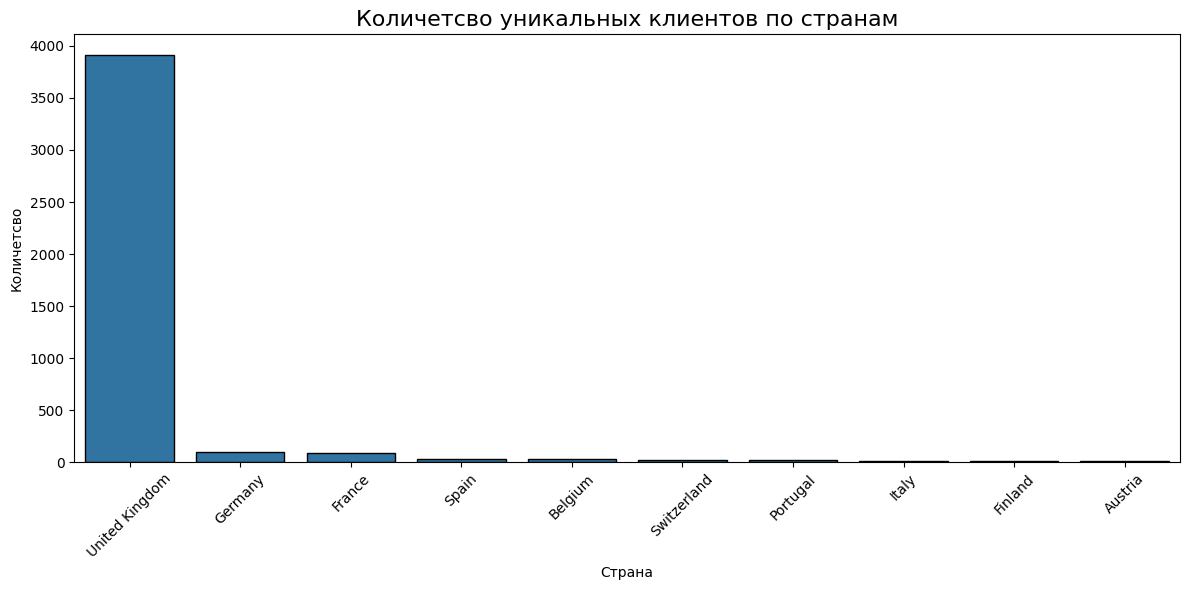

In [29]:
country_customer = data.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)[:10]

plt.figure(figsize=(12, 6))
sns.barplot(country_customer)
plt.title('Количетсво уникальных клиентов по странам', size=16)
plt.xlabel('Страна')
plt.ylabel('Количетсво')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Задание 4.2
Мы посмотрели на распределение клиентов в разрезе стран. А что насчёт заказов?

Постройте визуализацию и выделите топ-3 стран по количеству поступающих заказов.

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


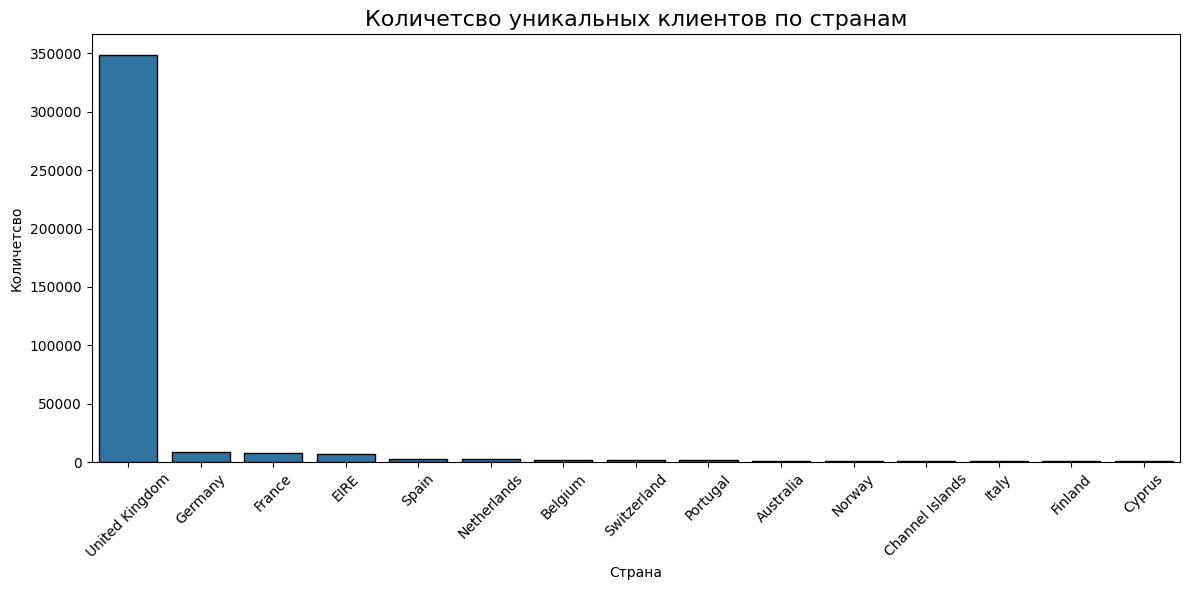

In [30]:
stock_customer = data.groupby('Country')['StockCode'].count().sort_values(ascending=False)[:15]

plt.figure(figsize=(12, 6))
sns.barplot(stock_customer)
plt.title('Количетсво уникальных клиентов по странам', size=16)
plt.xlabel('Страна')
plt.ylabel('Количетсво')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Задание 4.3
Давайте добавим в датасет общую цену заказа, назовём её TotalPrice.
Общая цена заказа рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Чему равна средняя общая стоимость заказов? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [31]:
data['TotalPrice'] = data['UnitPrice'] * (data['Quantity'] - data['QuantityCanceled'])
print('Средняя общая стоимость заказов: {} фунтов стерлингов'.format(round(data['TotalPrice'].mean())))

Средняя общая стоимость заказов: 21 фунтов стерлингов


### Задание 4.4

Постройте визуализацию и выделите топ-3 стран, клиенты из которых приносят компании больше всего выручки:
* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


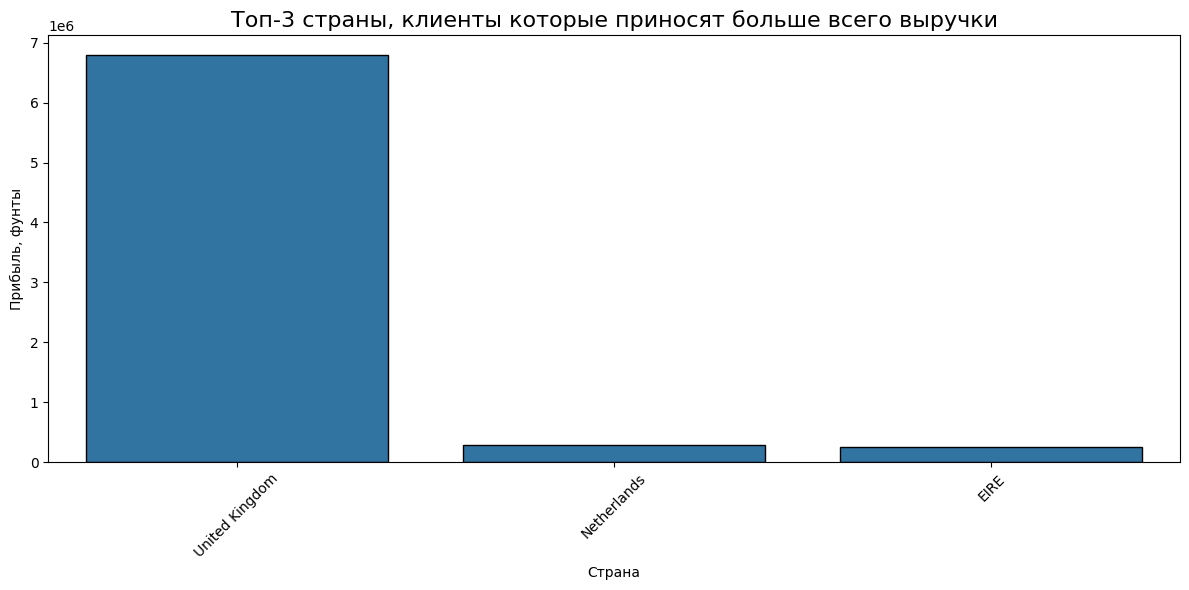

In [32]:
stock_customer = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)[:3]

plt.figure(figsize=(12, 6))
sns.barplot(stock_customer)
plt.title('Топ-3 страны, клиенты которые приносят больше всего выручки', size=16)
plt.xlabel('Страна')
plt.ylabel('Прибыль, фунты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Интересно, что Нидерланды находятся на шестом месте по количеству заказов, однако из-за того что эти заказы оптовые, по выручке Нидерланды находятся на втором месте.

Теперь займёмся временными характеристиками.


### Задание 4.5
Добавьте в таблицу с транзакциями признаки месяца, дня недели и часа совершения покупки.

Постройте визуализацию, отражающую распределение суммарной выручки от заказов по месяцам. Укажите номер самого прибыльного для компании месяца. Предположите, почему так происходит.

Самый прибыльный месяц: 11
Выручка в этом месяце: 1119205.84 фунтов


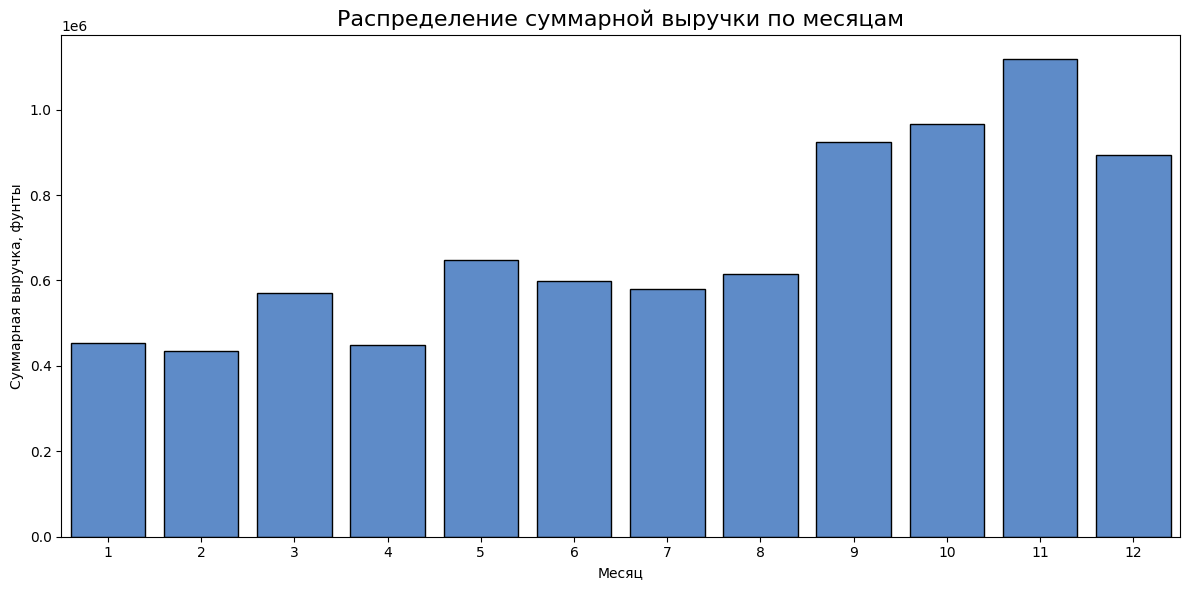

In [33]:
data['Month'] = data['InvoiceDate'].dt.month
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek
data['Hour'] = data['InvoiceDate'].dt.hour

# Группируем по месяцам и считаем суммарную выручку
monthly_revenue = data.groupby('Month')['TotalPrice'].sum()

# Находим самый прибыльный месяц
most_profitable_month = monthly_revenue.idxmax()
max_revenue = monthly_revenue.max()

print(f"Самый прибыльный месяц: {most_profitable_month}")
print(f"Выручка в этом месяце: {max_revenue:.2f} фунтов")

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, color='#4d89d9')
plt.title('Распределение суммарной выручки по месяцам', size=16)
plt.xlabel('Месяц')
plt.ylabel('Суммарная выручка, фунты')
plt.tight_layout()
plt.show()

>Вывод:
Это ноябрь. Такой результат объясняется довольно просто: ноябрь предшествует декабрю, а в декабре отмечаются католическое Рождество и Новый год. Так как мы анализируем данные магазина подарков, то совсем не удивительно, что мы видим максимальный рост продаж в преддверии этих праздников.

### Задание 4.6
Постройте визуализацию количества заказов для каждого дня недели. Укажите день недели, в который, согласно данным, не совершено ни одного заказа:
* Понедельник
* Вторник
* Среда
* Четверг
* Пятница
* Суббота 
* Воскресенье


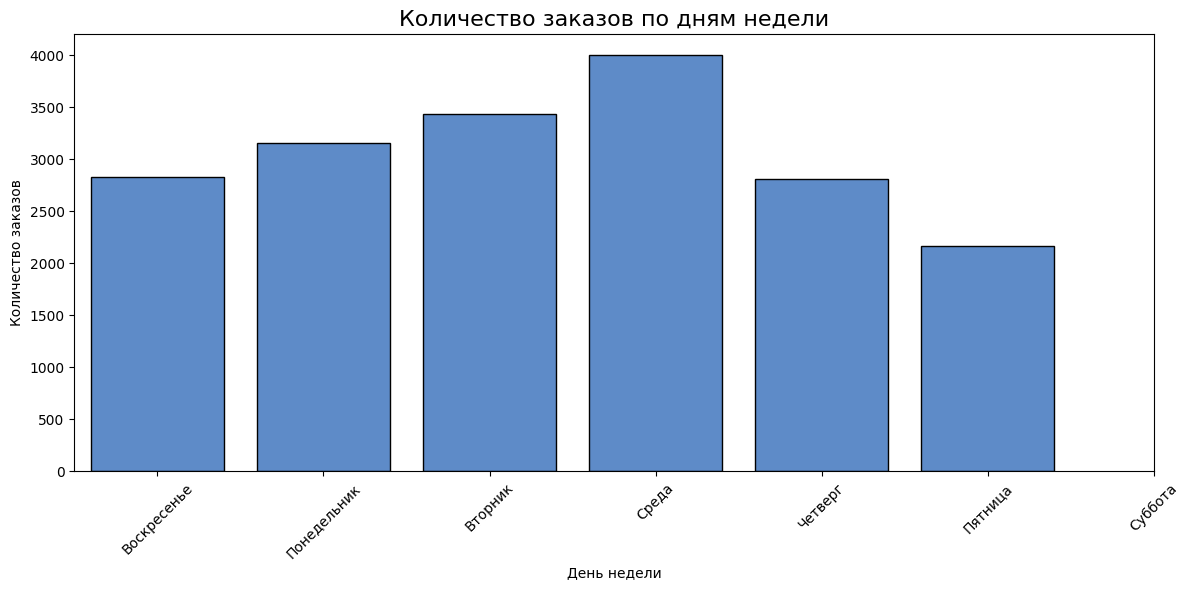

In [34]:
days_of_week_english = {
    0: 'Воскресенье',
    1: 'Понедельник', 
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота'
}

# Группируем по дню недели и считаем количество заказов
orders_by_day = data.groupby('DayOfWeek')['InvoiceNo'].nunique()

# Проверяем, есть ли дни без заказов
all_days = set(range(7))
days_with_orders = set(orders_by_day.index)
days_without_orders = all_days - days_with_orders

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=orders_by_day.index, y=orders_by_day.values, color='#4d89d9')
plt.title('Количество заказов по дням недели', size=16)
plt.xlabel('День недели')
plt.ylabel('Количество заказов')

# Подписываем оси названиями дней недели в правильном порядке
plt.xticks(ticks=range(7), labels=[days_of_week_english[i] for i in range(7)], rotation=45)
plt.tight_layout()
plt.show()

Действительно, согласно данным, нет ни одной транзакции, совершённой в субботу, что довольно странно. Возможно, суббота является выходным днём и транзакции в этот день не совершаются, а может быть, это ошибка в данных.

### Задание 4.7
Выделите дату из признака времени совершения транзакции.
Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.

Постройте визуализацию, отражающую распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции).

Выберите верные утверждения:
* Больше всего заказов совершается в дневное время в интервале от 18 до 20 часов
* Больше всего заказов совершается в вечернее время в интервале от 10 до 15 часов
* Начиная с 21 часа вечера и до 6 утра (не включительно) заказы не поступают 
* Заказы поступают во все периоды дня


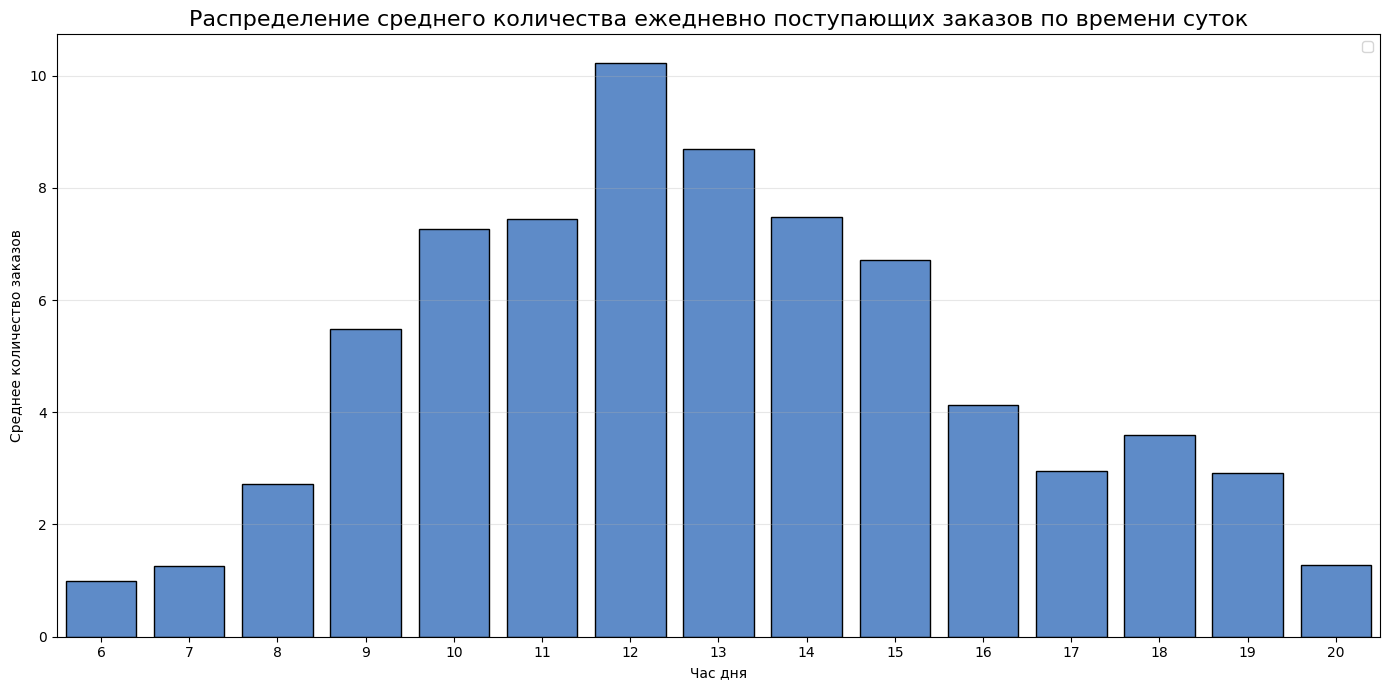

In [35]:
# Выделяем дату из времени транзакции
data['Date'] = data['InvoiceDate'].dt.date

# Группируем по дате и часу, считаем количество уникальных заказов
daily_hourly_orders = data.groupby(['Date', 'Hour'])['InvoiceNo'].nunique().reset_index()
daily_hourly_orders.columns = ['Date', 'Hour', 'OrdersCount']

# Находим среднее количество заказов по часам суток
avg_hourly_orders = daily_hourly_orders.groupby('Hour')['OrdersCount'].mean().reset_index()
avg_hourly_orders.columns = ['Hour', 'AvgOrders']

# Визуализация
plt.figure(figsize=(14, 7))
sns.barplot(data=avg_hourly_orders, x='Hour', y='AvgOrders', color='#4d89d9')
plt.title('Распределение среднего количества ежедневно поступающих заказов по времени суток', size=16)
plt.xlabel('Час дня')
plt.ylabel('Среднее количество заказов')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

> Вывод по визуализации:
- B Больше всего заказов совершается в дневное время, в интервале от 10 до 15 часов.
- С 21 часа до 5 утра заказы не поступают.

## 5. RFM-сегментация клиентов: часть 1

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
| Признак | Смысл |
|---|---|
| Recency | как давно клиент покупал |
| Frequency | сколько раз покупал |
| Monetary Value | сколько потратил |


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов.

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

### Задание 5.1

Итак, приступим к созданию нашей RFM-таблицы. 

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учетом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

In [36]:
import pandas as pd
import numpy as np

# Устанавливаем точку отсчета
reference_date = pd.to_datetime('2011-12-10 00:00:00')

# Создаем RFM-таблицу
rfm_table = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency (уникальные заказы)
    'TotalPrice': 'sum'      # Monetary Value
})

# Переименовываем столбцы
rfm_table = rfm_table.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency', 
    'TotalPrice': 'Monetary'
})

# Сортируем по CustomerID для наглядности
rfm_table = rfm_table.sort_index()

# Выводим первые строки таблицы
print("RFM-таблица (первые 10 строк):")
print(rfm_table.head(10))

# Базовая статистика по RFM-характеристикам
print("\nСтатистика RFM-характеристик:")
print(rfm_table.describe())

RFM-таблица (первые 10 строк):
            Recency  Frequency  Monetary
CustomerID                              
12346           325          1      0.00
12347             2          7   4310.00
12348            75          4   1437.24
12349            18          1   1457.55
12350           310          1    294.40
12352            36          7   1265.41
12353           204          1     89.00
12354           232          1   1079.40
12355           214          1    459.40
12356            22          3   2487.43

Статистика RFM-характеристик:
           Recency    Frequency       Monetary
count  4334.000000  4334.000000    4334.000000
mean     92.226581     4.245962    1904.292771
std     100.175327     7.634989    8277.913479
min       0.000000     1.000000       0.000000
25%      17.000000     1.000000     298.257500
50%      50.000000     2.000000     650.590000
75%     142.000000     5.000000    1602.775000
max     373.000000   206.000000  278742.020000


1) Сколько клиентов совершили покупку более 200 дней назад?

2) Сколько заказов в среднем делает клиент (за представленный годовой период)? Ответ округлите до целого числа.

3) Чему равна общая сумма денег, которую потратил клиент с идентификатором 12360? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [37]:
# 1) Клиенты, совершившие покупку более 200 дней назад
clients_200_days = rfm_table[rfm_table['Recency'] > 200]
print(f"1) Клиентов с покупкой более 200 дней назад: {len(clients_200_days)}")

# 2) Среднее количество заказов на клиента
avg_orders = rfm_table['Frequency'].mean()
print(f"2) Среднее количество заказов на клиента: {round(avg_orders)}")

# 3) Общая сумма клиента с ID 12360
customer_12360 = rfm_table.loc['12360', 'Monetary']
print(f"3) Общая сумма клиента 12360: {round(customer_12360)} фунтов")

1) Клиентов с покупкой более 200 дней назад: 743
2) Среднее количество заказов на клиента: 4
3) Общая сумма клиента 12360: 2302 фунтов


Теперь давайте взглянем на коробчатые диаграммы для каждого из признаков:

In [38]:
boxes = [px.box(rfm_table, x=column) for column in rfm_table.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.write_html('../assets/rfm_boxplots_before_outlier_removal.html', include_plotlyjs='cdn')
fig.show()

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


### Задание 5.2
Удалите из RFM-таблицы записи о клиентах, для которых выполняется хотя бы одно из условий:

$$frequency > frequency_{0.95}$$
$$monetary > monetary_{0.95}$$ 

In [39]:
# Рассчитываем 95% квантили для Frequency и MonetaryValue
freq_95 = rfm_table['Frequency'].quantile(0.95)
monetary_95 = rfm_table['Monetary'].quantile(0.95)

print(f"95% квантиль Frequency: {freq_95}")
print(f"95% квантиль Monetary: {monetary_95}")

# Удаляем клиентов, у которых Frequency или MonetaryValue превышают 95% квантиль
rfm_cleaned = rfm_table[
    (rfm_table['Frequency'] <= freq_95) & 
    (rfm_table['Monetary'] <= monetary_95)
]

print(f"Исходное количество клиентов: {len(rfm_table)}")
print(f"Количество клиентов после удаления выбросов: {len(rfm_cleaned)}")
print(f"Удалено клиентов: {len(rfm_table) - len(rfm_cleaned)}")

# Проверяем статистику после очистки
print("\nСтатистика после удаления выбросов:")
print(rfm_cleaned.describe())

95% квантиль Frequency: 13.0
95% квантиль Monetary: 5628.147499999977
Исходное количество клиентов: 4334
Количество клиентов после удаления выбросов: 4044
Удалено клиентов: 290

Статистика после удаления выбросов:
           Recency    Frequency     Monetary
count  4044.000000  4044.000000  4044.000000
mean     97.485410     3.009644   975.516800
std     101.181582     2.538383  1024.094958
min       0.000000     1.000000     0.000000
25%      21.000000     1.000000   280.812500
50%      56.000000     2.000000   594.340000
75%     155.000000     4.000000  1307.187500
max     373.000000    13.000000  5589.830000


После удаления выбросов у вас должны получиться следующие коробчатые диаграммы:


In [40]:
boxes = [px.box(rfm_cleaned, x=column) for column in rfm_cleaned.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency", "Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.write_html('../assets/rfm_boxplots_after_outlier_removal.html', include_plotlyjs='cdn')
fig.show()

Мы наконец добрались до этапа кластеризации. Для начала нам необходимо оценить, как распределены наблюдения в пространстве признаков. Благо, у нас всего три параметра, по которым мы хотим кластеризовать клиентов, поэтому данные можно визуализировать в виде трёхмерной диаграммы рассеяния. 

Построим визуализацию нашего трёхмерного пространства признаков:


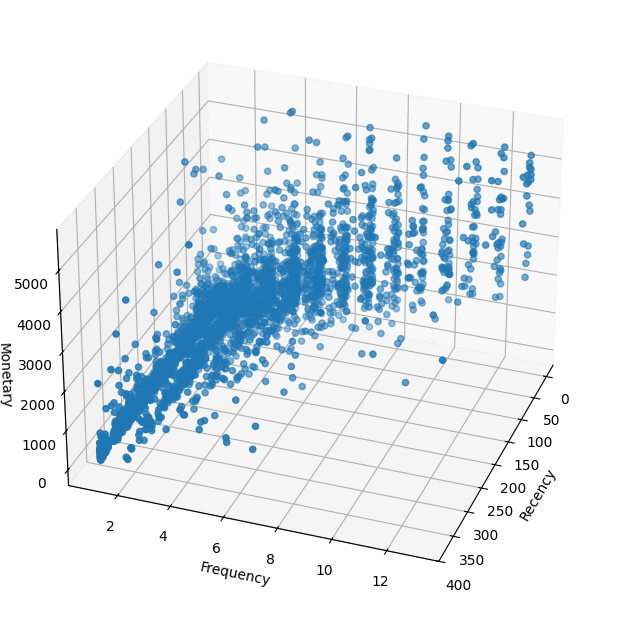

In [41]:
# создадим трёхмерный объект
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
# добавим дополнительную ось в объект картинки
fig.add_axes(ax)
ax.azim = 20
ax.elev = 30

# визуализируем данные, передав значения x, y, z, а также информацию о группировке данных по цветам
ax.scatter(
    rfm_cleaned['Recency'].to_list(), 
    rfm_cleaned['Frequency'].to_list(),
    rfm_cleaned['Monetary'].to_list()
)
# добавим оси
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary');

Что здесь можно увидеть? На самом деле, ничего конкретного. Да, видно, что есть клиенты с большими значениями параметров Monetary и Frequency — вероятно, это лучшие клиенты, которые покупают чаще всего и приносят больше всего денег. Однако по общей массе точек сложно сказать, сколько кластеров у нас есть — скорее даже кажется, что пространство не поддаётся кластеризации.

Давайте призовём на помощь методы снижения размерности.


### Задание 5.3
Начнём с метода главных компонент (PCA). Нам известно, что для его стабильной работы данные необходимо стандартизировать/нормализовать. 

Давайте для удобства обернём эти шаги по предобработке данных в pipeline.

Создайте pipeline, в котором будут следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* метод главных компонент с двумя компонентами.

Обучите ваш pipeline на RFM-таблице, очищенной от выбросов, и примените к ней трансформацию.

Какую долю дисперсии исходных данных объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.



Доля дисперсии, объясняемая первой главной компонентой: 0.68
Доля дисперсии, объясняемая второй главной компонентой: 0.24
Суммарная доля объясненной дисперсии: 0.92


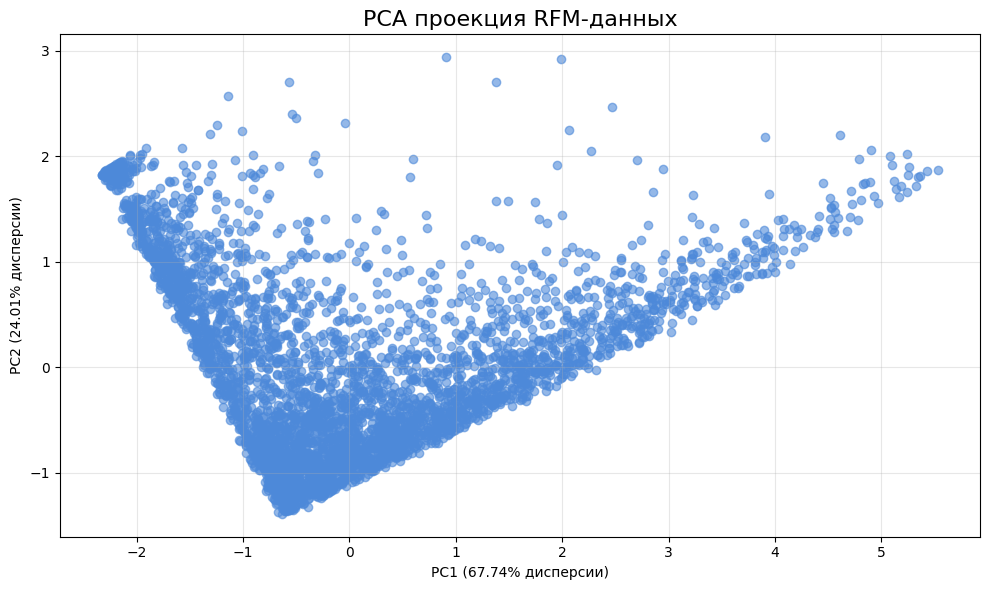

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA(n_components=2))
])

# Обучаем pipeline на очищенной RFM-таблице и применяем трансформацию
rfm_pca = pipeline.fit_transform(rfm_cleaned)

# Получаем объект PCA из pipeline для доступа к объясненной дисперсии
pca_model = pipeline.named_steps['pca']
explained_variance_ratio = pca_model.explained_variance_ratio_

print(f"Доля дисперсии, объясняемая первой главной компонентой: {explained_variance_ratio[0]:.2f}")
print(f"Доля дисперсии, объясняемая второй главной компонентой: {explained_variance_ratio[1]:.2f}")
print(f"Суммарная доля объясненной дисперсии: {explained_variance_ratio.sum():.2f}")

# Визуализация результатов PCA
plt.figure(figsize=(10, 6))
plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], alpha=0.6, c='#4d89d9')
plt.title('PCA проекция RFM-данных', size=16)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2%} дисперсии)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Попробуем разделить это пространство главных компонент на сегменты. 

### Задание 5.4
Попробуем воспользоваться методом k-means. 

Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


Кластеров: 2, Коэффициент силуэта: 0.4551


Кластеров: 3, Коэффициент силуэта: 0.5452


Кластеров: 4, Коэффициент силуэта: 0.4626


Кластеров: 5, Коэффициент силуэта: 0.4725


Кластеров: 6, Коэффициент силуэта: 0.4402


Кластеров: 7, Коэффициент силуэта: 0.4013


Кластеров: 8, Коэффициент силуэта: 0.3841


Кластеров: 9, Коэффициент силуэта: 0.3859


Кластеров: 10, Коэффициент силуэта: 0.3996

1) Оптимальное количество кластеров: 3
2) Максимальное значение коэффициента силуэта: 0.55


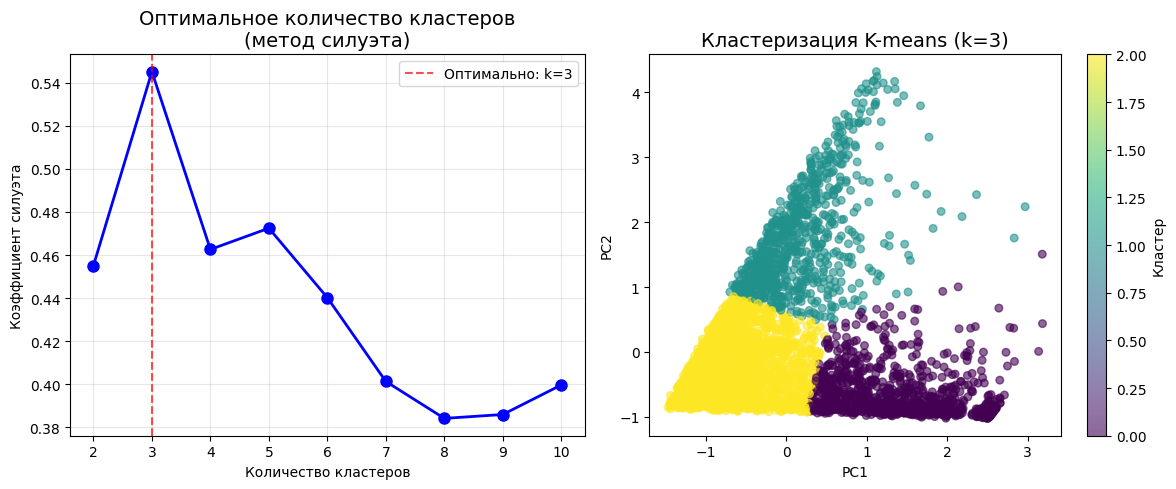

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_scaled = StandardScaler().fit_transform(rfm_pca)

# Перебираем количество кластеров от 2 до 10
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Кластеров: {k}, Коэффициент силуэта: {silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
kmeans_best_k = k_range[np.argmax(silhouette_scores)]
kmeans_best_silhouette = max(silhouette_scores)

print(f"\n1) Оптимальное количество кластеров: {kmeans_best_k}")
print(f"2) Максимальное значение коэффициента силуэта: {kmeans_best_silhouette:.2f}")

# Визуализация результатов
plt.figure(figsize=(12, 5))

# График коэффициента силуэта
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=kmeans_best_k, color='red', linestyle='--', alpha=0.7, label=f'Оптимально: k={kmeans_best_k}')
plt.title('Оптимальное количество кластеров\n(метод силуэта)', size=14)
plt.xlabel('Количество кластеров')
plt.ylabel('Коэффициент силуэта')
plt.grid(alpha=0.3)
plt.legend()

# Визуализация кластеров для оптимального k
plt.subplot(1, 2, 2)
kmeans_optimal = KMeans(n_clusters=kmeans_best_k, random_state=42)
cluster_labels_optimal = kmeans_optimal.fit_predict(X_scaled)

# Проецируем на первые две главные компоненты для визуализации
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=cluster_labels_optimal, 
            cmap='viridis', alpha=0.6, s=30)
plt.title(f'Кластеризация K-means (k={kmeans_best_k})', size=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Кластер')

plt.tight_layout()
plt.show()

### Задание 5.5
Теперь возьмём EM-алгоритм.

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture) с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно.
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


Кластеров: 2, Коэффициент силуэта: 0.3563


Кластеров: 3, Коэффициент силуэта: 0.4624


Кластеров: 4, Коэффициент силуэта: 0.3168


Кластеров: 5, Коэффициент силуэта: 0.2490


Кластеров: 6, Коэффициент силуэта: 0.2078


Кластеров: 7, Коэффициент силуэта: 0.1574


Кластеров: 8, Коэффициент силуэта: 0.1498


Кластеров: 9, Коэффициент силуэта: 0.1519


Кластеров: 10, Коэффициент силуэта: 0.1178

1) Оптимальное количество кластеров для EM-алгоритма: 3
2) Максимальное значение коэффициента силуэта: 0.46


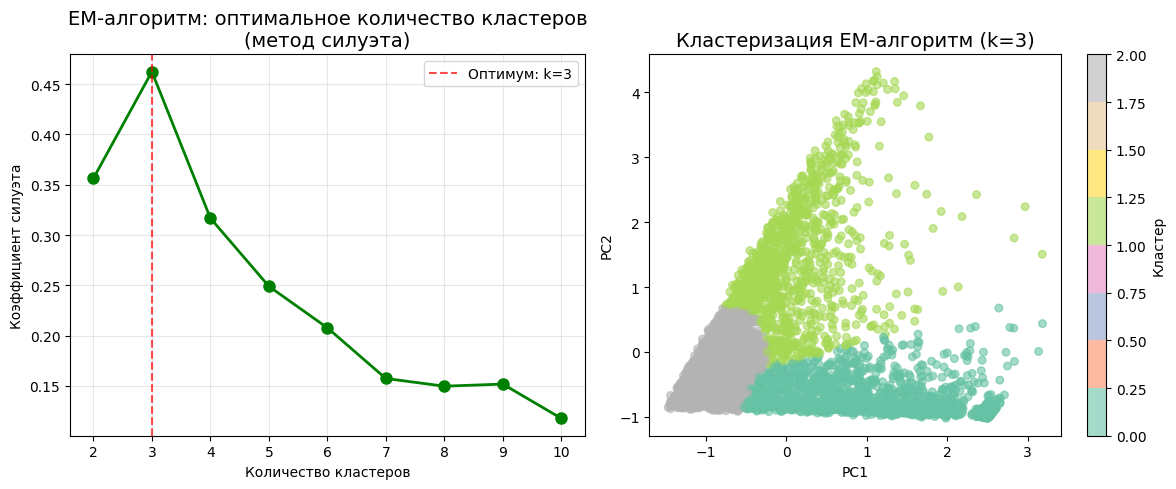

In [44]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

X_scaled = StandardScaler().fit_transform(rfm_pca)

# Перебираем количество кластеров от 2 до 10
k_range = range(2, 11)
silhouette_scores_gmm = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores_gmm.append(silhouette_avg)
    print(f"Кластеров: {k}, Коэффициент силуэта: {silhouette_avg:.4f}")
    
# Находим оптимальное количество кластеров
gmm_best_k = k_range[np.argmax(silhouette_scores_gmm)]
gmm_best_silhouette = max(silhouette_scores_gmm)

print(f"\n1) Оптимальное количество кластеров для EM-алгоритма: {gmm_best_k}")
print(f"2) Максимальное значение коэффициента силуэта: {gmm_best_silhouette:.2f}")

# Визуализация результатов
plt.figure(figsize=(12, 5))

# График коэффициента силуэта
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores_gmm, 'go-', linewidth=2, markersize=8)
plt.axvline(x=gmm_best_k, color='red', linestyle='--', alpha=0.7, label=f'Оптимум: k={gmm_best_k}')
plt.title('EM-алгоритм: оптимальное количество кластеров\n(метод силуэта)', size=14)
plt.xlabel('Количество кластеров')
plt.ylabel('Коэффициент силуэта')
plt.grid(alpha=0.3)
plt.legend()

# Визуализация кластеров для оптимального k
plt.subplot(1, 2, 2)
gmm_optimal = GaussianMixture(n_components=gmm_best_k, random_state=42)
cluster_labels_optimal = gmm_optimal.fit_predict(X_scaled)

# Проецируем на первые две главные компоненты для визуализации
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=cluster_labels_optimal, 
                     cmap='Set2', alpha=0.6, s=30)
plt.title(f'Кластеризация EM-алгоритм (k={gmm_best_k})', size=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Кластер')

plt.tight_layout()
plt.show()

### Задание 5.6
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [45]:
# 1) Сравнение моделей и определение лучшей
print("СРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ:")
print("=" * 50)

# Предположим, что у нас есть результаты из предыдущих заданий
# Замените эти значения на ваши реальные результаты
print(f"K-Means (k={kmeans_best_k}): коэффициент силуэта = {kmeans_best_silhouette:.4f}")
print(f"GaussianMixture (k={gmm_best_k}): коэффициент силуэта = {gmm_best_silhouette:.4f}")

if kmeans_best_silhouette > gmm_best_silhouette:
    best_model_name = "K-Means"
    best_k = kmeans_best_k
    best_silhouette = kmeans_best_silhouette
    best_model = KMeans(n_clusters=best_k, random_state=42)
else:
    best_model_name = "GaussianMixture"
    best_k = gmm_best_k
    best_silhouette = gmm_best_silhouette
    best_model = GaussianMixture(n_components=best_k, random_state=42)

print(f"\n1) Лучшая модель: {best_model_name}")
print(f"   Количество кластеров: {best_k}")
print(f"   Коэффициент силуэта: {best_silhouette:.4f}")

# 2) Обучаем лучшую модель на декомпозированных данных (PCA)
# Создаем pipeline с PCA и лучшей моделью кластеризации
pipeline_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),  # 2 компоненты для визуализации
    ('cluster', best_model)
])

# Обучаем pipeline и получаем метки кластеров
cluster_labels_best = pipeline_best.fit_predict(rfm_cleaned)

# Анализируем распределение кластеров
unique, counts = np.unique(cluster_labels_best, return_counts=True)
cluster_distribution = dict(zip(unique, counts))

print("\nРаспределение клиентов по кластерам:")
for cluster_id, count in cluster_distribution.items():
    print(f"Кластер {cluster_id}: {count} клиентов")

# Находим самый большой кластер
largest_cluster_id = max(cluster_distribution, key=cluster_distribution.get)
largest_cluster_size = cluster_distribution[largest_cluster_id]

print(f"\n2) Самый большой кластер: {largest_cluster_id}")
print(f"   Количество клиентов в самом большом кластере: {largest_cluster_size}")

СРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ:
K-Means (k=3): коэффициент силуэта = 0.5452
GaussianMixture (k=3): коэффициент силуэта = 0.4624

1) Лучшая модель: K-Means
   Количество кластеров: 3
   Коэффициент силуэта: 0.5452

Распределение клиентов по кластерам:
Кластер 0: 999 клиентов
Кластер 1: 2269 клиентов
Кластер 2: 776 клиентов

2) Самый большой кластер: 1
   Количество клиентов в самом большом кластере: 2269


Итак, у нас есть три сегмента клиентов. Давайте попробуем составить профиль для этих сегментов.

### Задание 5.7

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице, очищенной от выбросов.  Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чему равно максимальное среднее значение признака Frequency в полученной таблице? Ответ округлите до целого числа.

In [46]:
# Группируем RFM-таблицу по кластерам и считаем средние значения
rfm_with_clusters = rfm_cleaned.copy()
rfm_with_clusters['Cluster'] = cluster_labels_best

cluster_profiles = rfm_with_clusters.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("Профили кластеров (средние значения):")
print(cluster_profiles)

# Находим максимальное среднее значение Frequency
max_frequency = cluster_profiles['Frequency'].max()
print(f"\nМаксимальное среднее значение Frequency: {max_frequency}")
print(f"Округленное до целого: {round(max_frequency)}")

# Дополнительная статистика по кластерам
cluster_sizes = rfm_with_clusters.groupby('Cluster').size()
print(f"\nРазмеры кластеров:")
print(cluster_sizes)

Профили кластеров (средние значения):
         Recency  Frequency  Monetary
Cluster                              
0         253.47       1.40    386.17
1          51.22       2.33    659.79
2          31.94       7.07   2657.39

Максимальное среднее значение Frequency: 7.07
Округленное до целого: 7

Размеры кластеров:
Cluster
0     999
1    2269
2     776
dtype: int64


### Полярная диаграмма
Сейчас мы познакомимся с одним из способов визуализации профиля кластеров — Radar Chart (полярная, или лепестковая, диаграмма). Это графическое представление значений нескольких эквивалентных категорий в форме «паутины».
Radar Chart очень часто используется в контексте определения профиля кластеров. На концах «паутины» откладываются оси, которые соответствуют признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 
Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На данной диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие к данному кластеру, в большей степени увлекаются музыкой (Music), а в меньшей степени — программированием (Programm).

В модуле graph_objects библиотеки plotly есть встроенная функция Scatterpolar, которая позволяет построить полярную диаграмму. На основе этой функции мы реализовали собственную функцию plot_cluster_profile(), которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У этой функции два параметра: grouped_data — сгруппированные по кластерам характеристики объектов (клиентов), n_clusters — количество кластеров. 

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в реализацию функции plot_cluster_profile().

In [47]:
def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()

Теперь у нас есть удобный инструмент для анализа профиля кластеров. Давайте воспользуемся им.


### Задание 5.8

Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера. 

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

Описание кластера:
* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «промежуточным» клиентам, которые являются активными, но покупают не так часто и много, как лояльные клиенты. В то же время эти клиенты не являются «потерянными».
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена очень давно.



АНАЛИЗ КЛАСТЕРОВ И СОПОСТАВЛЕНИЕ С ОПИСАНИЯМИ:

СОПОСТАВЛЕНИЕ КЛАСТЕРОВ:

Кластер 2: Лояльные клиенты
  Recency: 31.9 дней
  Frequency: 7.1 заказов
  Monetary: £2657.4
  Размер кластера: 776 клиентов

Кластер 0: Потерянные клиенты
  Recency: 253.5 дней
  Frequency: 1.4 заказов
  Monetary: £386.2
  Размер кластера: 999 клиентов

Кластер 1: Промежуточные клиенты
  Recency: 51.2 дней
  Frequency: 2.3 заказов
  Monetary: £659.8
  Размер кластера: 2269 клиентов


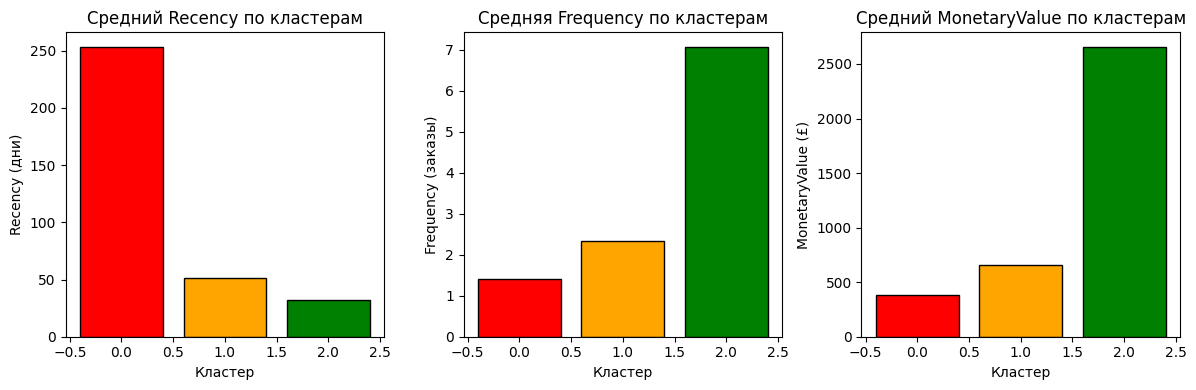


ИТОГОВЫЕ ОТВЕТЫ:
Задание 5.7: Максимальное среднее значение Frequency = 7

Задание 5.8: Сопоставление кластеров:
  Кластер 2 → Лояльные клиенты
  Кластер 0 → Потерянные клиенты
  Кластер 1 → Промежуточные клиенты


In [48]:
# Строим полярную диаграмму профилей кластеров
plot_cluster_profile(cluster_profiles, len(cluster_profiles))

# Анализируем кластеры и сопоставляем с описаниями
print("\nАНАЛИЗ КЛАСТЕРОВ И СОПОСТАВЛЕНИЕ С ОПИСАНИЯМИ:")
print("=" * 60)

# Сортируем кластеры по характеристикам для анализа
clusters_analyzed = []

for cluster_id in cluster_profiles.index:
    recency = cluster_profiles.loc[cluster_id, 'Recency']
    frequency = cluster_profiles.loc[cluster_id, 'Frequency']
    monetary = cluster_profiles.loc[cluster_id, 'Monetary']
    size = cluster_sizes.loc[cluster_id]
    
    clusters_analyzed.append({
        'cluster_id': cluster_id,
        'recency': recency,
        'frequency': frequency,
        'monetary': monetary,
        'size': size
    })

# Сортируем по Recency (чем меньше, тем лучше) и Frequency (чем больше, тем лучше)
clusters_sorted_recency = sorted(clusters_analyzed, key=lambda x: x['recency'])
clusters_sorted_frequency = sorted(clusters_analyzed, key=lambda x: x['frequency'], reverse=True)
clusters_sorted_monetary = sorted(clusters_analyzed, key=lambda x: x['monetary'], reverse=True)

# Определяем типы кластеров
cluster_types = {}

# Лояльные клиенты - лучшие по всем показателям
loyal_cluster = min(clusters_analyzed, key=lambda x: (x['recency'], -x['frequency'], -x['monetary']))
cluster_types[loyal_cluster['cluster_id']] = "Лояльные клиенты"

# Потерянные клиенты - худшие по всем показарам
lost_cluster = max(clusters_analyzed, key=lambda x: (x['recency'], -x['frequency'], -x['monetary']))
cluster_types[lost_cluster['cluster_id']] = "Потерянные клиенты"

# Промежуточные клиенты - оставшийся кластер
for cluster in clusters_analyzed:
    if cluster['cluster_id'] not in [loyal_cluster['cluster_id'], lost_cluster['cluster_id']]:
        cluster_types[cluster['cluster_id']] = "Промежуточные клиенты"

# Выводим результаты анализа
print("\nСОПОСТАВЛЕНИЕ КЛАСТЕРОВ:")
for cluster_id, description in cluster_types.items():
    cluster_data = cluster_profiles.loc[cluster_id]
    print(f"\nКластер {cluster_id}: {description}")
    print(f"  Recency: {cluster_data['Recency']:.1f} дней")
    print(f"  Frequency: {cluster_data['Frequency']:.1f} заказов")
    print(f"  Monetary: £{cluster_data['Monetary']:.1f}")
    print(f"  Размер кластера: {cluster_sizes.loc[cluster_id]} клиентов")

# Альтернативная визуализация для лучшего понимания
plt.figure(figsize=(12, 4))

# График 1: Recency по кластерам
plt.subplot(1, 3, 1)
colors = ['green' if cluster_types[i] == "Лояльные клиенты" else 
          'orange' if cluster_types[i] == "Промежуточные клиенты" else 
          'red' for i in cluster_profiles.index]
plt.bar(cluster_profiles.index, cluster_profiles['Recency'], color=colors)
plt.title('Средний Recency по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Recency (дни)')

# График 2: Frequency по кластерам
plt.subplot(1, 3, 2)
plt.bar(cluster_profiles.index, cluster_profiles['Frequency'], color=colors)
plt.title('Средняя Frequency по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Frequency (заказы)')

# График 3: MonetaryValue по кластерам
plt.subplot(1, 3, 3)
plt.bar(cluster_profiles.index, cluster_profiles['Monetary'], color=colors)
plt.title('Средний MonetaryValue по кластерам')
plt.xlabel('Кластер')
plt.ylabel('MonetaryValue (£)')

plt.tight_layout()
plt.show()

# Итоговые ответы
print("\n" + "=" * 60)
print("ИТОГОВЫЕ ОТВЕТЫ:")
print(f"Задание 5.7: Максимальное среднее значение Frequency = {round(max_frequency)}")
print("\nЗадание 5.8: Сопоставление кластеров:")
for cluster_id, description in cluster_types.items():
    print(f"  Кластер {cluster_id} → {description}")

### 4. RFM-сегментация клиентов: часть 2

Итак, с помощью RFM-анализа нам удалось выделить три сегмента клиентов. Однако в маркетинге принято оперировать большим их количеством: обычно маркетологи стараются создать стратегию хотя бы для пяти-семи клиентских сегментов в градации от «лояльных» до «потерянных» с промежуточными категориями.

Поэтому, получив обратную связь от маркетологов, мы вновь принимаемся за работу, пытаясь модифицировать полученное решение.

Ранее мы производили кластеризацию в пространстве главных компонент. Вспомним, что PCA является линейным методом отображения исходного пространства признаков в его сжатую версию.

А что если использовать нелинейную трансформацию? Например, алгоритм снижения размерности t-SNE. Давайте попробуем и посмотрим, что получится.

### Задание 6.1
Воспользуемся алгоритмом t-SNE и трансформируем RFM-таблицу, очищенную от выбросов, в двухмерное представление. Также заранее позаботимся о масштабировании признаков.

Давайте для удобства обернём шаги по предобработке данных в pipeline.

Создайте pipeline, который будет содержать следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* алгоритм t-SNE с двумя компонентами, параметрами perplexity=50 и random_state=100.

Обучите ваш pipeline на RFM-таблице (очищенной от выбросов), полученной ранее, и примените к ней трансформацию.

Чему равно значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE? Ответ округлите до двух знаков после точки-разделителя.

**Примечание:**
Напомним, что дивергенция Кульбака-Лейблера - это функция потерь, которая минимизируется при обучения алгоритма t-SNE. Она показывает меру расстояния между двумя распределениями. 

Оптимальное значение данной характеристики, найденное в процессе обучения алгоритма t-SNE, хранится в атрибуте kl_divergence_ объекта класса TSNE из библиотеки sklearn. Конечно же, предварительно модель необходимо обучить, чтобы получить это значение.



Значение дивергенции Кульбака-Лейблера: 0.5412
Округленное значение: 0.54


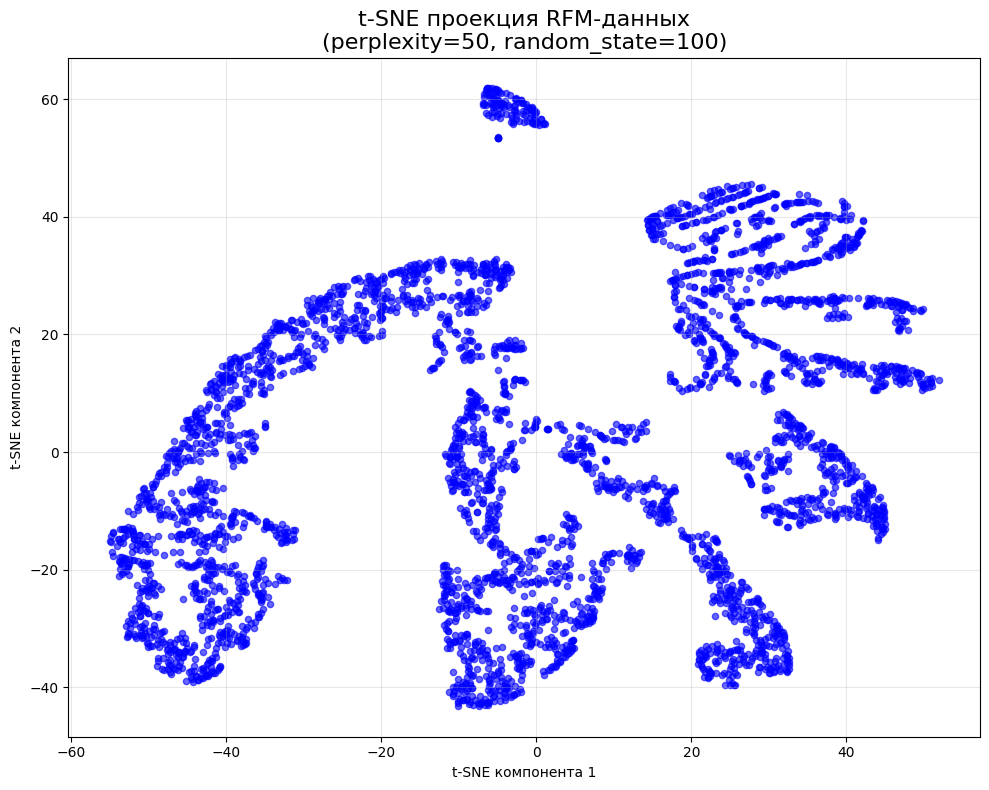

In [49]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Создаем pipeline с StandardScaler и t-SNE
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Стандартизация
    ('tsne', TSNE(n_components=2, perplexity=50, random_state=100))  # t-SNE
])

# Обучаем pipeline на очищенной RFM-таблице и применяем трансформацию
rfm_tsne = tsne_pipeline.fit_transform(rfm_cleaned)

# Получаем объект t-SNE из pipeline для доступа к атрибутам
tsne_model = tsne_pipeline.named_steps['tsne']
kl_divergence = tsne_model.kl_divergence_

print(f"Значение дивергенции Кульбака-Лейблера: {kl_divergence:.4f}")
print(f"Округленное значение: {kl_divergence:.2f}")

# Визуализация результатов t-SNE
plt.figure(figsize=(10, 8))
plt.scatter(rfm_tsne[:, 0], rfm_tsne[:, 1], alpha=0.6, s=20, c='blue')
plt.title('t-SNE проекция RFM-данных\n(perplexity=50, random_state=100)', size=16)
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

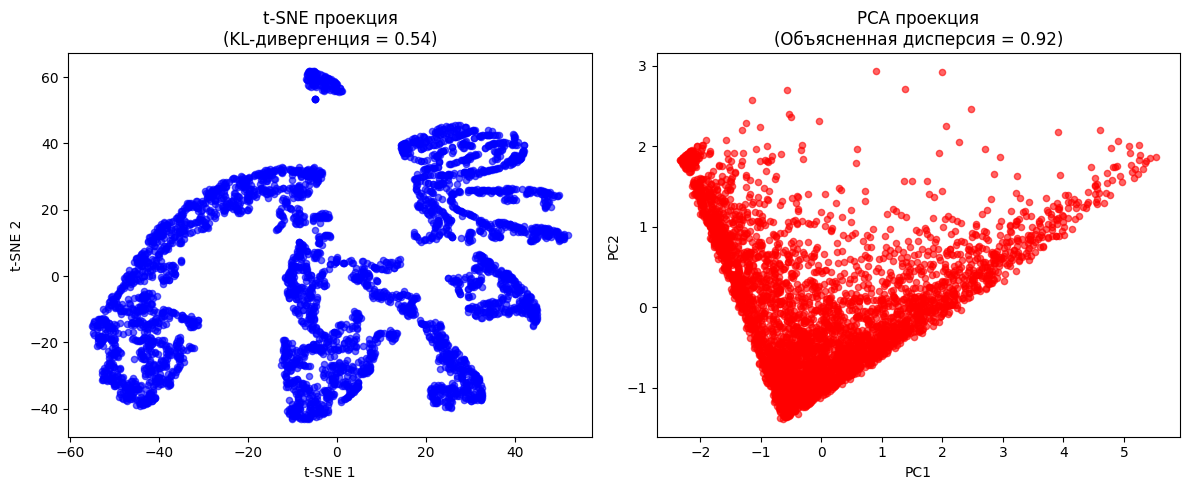

In [50]:
# Сравнение t-SNE и PCA
plt.figure(figsize=(12, 5))

# t-SNE проекция
plt.subplot(1, 2, 1)
plt.scatter(rfm_tsne[:, 0], rfm_tsne[:, 1], alpha=0.6, s=20, c='blue')
plt.title('t-SNE проекция\n(KL-дивергенция = {:.2f})'.format(kl_divergence))
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# PCA проекция (для сравнения)
pca_comparison = PCA(n_components=2)
X_pca_comparison = pca_comparison.fit_transform(StandardScaler().fit_transform(rfm_cleaned))
explained_variance = pca_comparison.explained_variance_ratio_.sum()

plt.subplot(1, 2, 2)
plt.scatter(X_pca_comparison[:, 0], X_pca_comparison[:, 1], alpha=0.6, s=20, c='red')
plt.title('PCA проекция\n(Объясненная дисперсия = {:.2f})'.format(explained_variance))
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

Как и ожидалось от t-SNE, алгоритм сгруппировал наиболее похожие объекты в подобие кластеров, причём эти кластеры легко определить.

Теперь давайте воспользуемся алгоритмами кластеризации, чтобы сформировать новые сегменты клиентов.


### Задание 6.2
Попробуем воспользоваться методом k-means. 
Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Используем t-SNE данные из предыдущего задания
X_tsne = rfm_tsne

# Подбираем оптимальное количество кластеров для K-means
k_range_62 = range(3, 9)
silhouette_scores_kmeans = []

print("K-MEANS КЛАСТЕРИЗАЦИЯ (на t-SNE данных):")
print("K\tSilhouette")
print("-" * 20)

for k in k_range_62:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_tsne)
    silhouette_avg = silhouette_score(X_tsne, cluster_labels)
    silhouette_scores_kmeans.append(silhouette_avg)
    print(f"{k}\t{silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_k_kmeans = k_range_62[np.argmax(silhouette_scores_kmeans)]
best_silhouette_kmeans = max(silhouette_scores_kmeans)

print(f"\n1) Оптимальное количество кластеров для K-means: {best_k_kmeans}")
print(f"2) Максимальное значение коэффициента силуэта: {best_silhouette_kmeans:.2f}")

K-MEANS КЛАСТЕРИЗАЦИЯ (на t-SNE данных):
K	Silhouette
--------------------


3	0.4309


4	0.4785


5	0.4518


6	0.4773


7	0.4776


8	0.4948

1) Оптимальное количество кластеров для K-means: 8
2) Максимальное значение коэффициента силуэта: 0.49


### Задание 6.3
Попробуем воспользоваться EM-алгоритом. 

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture)  с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.

In [52]:
from sklearn.mixture import GaussianMixture

# Подбираем оптимальное количество кластеров для EM-алгоритма
k_range_63 = range(3, 9)
silhouette_scores_gmm = []

print("\nEM-АЛГОРИТМ (GaussianMixture) на t-SNE данных:")
print("K\tSilhouette")
print("-" * 20)

for k in k_range_63:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_tsne)
    silhouette_avg = silhouette_score(X_tsne, cluster_labels)
    silhouette_scores_gmm.append(silhouette_avg)
    print(f"{k}\t{silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_k_gmm = k_range_63[np.argmax(silhouette_scores_gmm)]
best_silhouette_gmm = max(silhouette_scores_gmm)

print(f"\n1) Оптимальное количество кластеров для EM-алгоритма: {best_k_gmm}")
print(f"2) Максимальное значение коэффициента силуэта: {best_silhouette_gmm:.2f}")


EM-АЛГОРИТМ (GaussianMixture) на t-SNE данных:
K	Silhouette
--------------------


3	0.4284


4	0.4683


5	0.3915


6	0.4543


7	0.4499


8	0.4586

1) Оптимальное количество кластеров для EM-алгоритма: 4
2) Максимальное значение коэффициента силуэта: 0.47


### Задание 6.4
Наконец, попробуем воспользоваться алгоритмом алгомеративной кластеризации (AgglomerativeClustering).

Подберите оптимальное количество кластеров для алгоритма агломеративной кластеризации с помощью коэффициента силуэта, перебирая возможные значения от 2 до 8 включительно. 

Все параметры, за исключением числа кластеров, оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [53]:
from sklearn.cluster import AgglomerativeClustering

# Подбираем оптимальное количество кластеров для агломеративной кластеризации
k_range_64 = range(2, 9)
silhouette_scores_agg = []

print("\nАГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ на t-SNE данных:")
print("K\tSilhouette")
print("-" * 20)

for k in k_range_64:
    agg = AgglomerativeClustering(n_clusters=k)
    cluster_labels = agg.fit_predict(X_tsne)
    silhouette_avg = silhouette_score(X_tsne, cluster_labels)
    silhouette_scores_agg.append(silhouette_avg)
    print(f"{k}\t{silhouette_avg:.4f}")

# Находим оптимальное количество кластеров
best_k_agg = k_range_64[np.argmax(silhouette_scores_agg)]
best_silhouette_agg = max(silhouette_scores_agg)

print(f"\n1) Оптимальное количество кластеров для агломеративной кластеризации: {best_k_agg}")
print(f"2) Максимальное значение коэффициента силуэта: {best_silhouette_agg:.2f}")


АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ на t-SNE данных:
K	Silhouette
--------------------


2	0.3805


3	0.4241


4	0.4558


5	0.4705


6	0.4693


7	0.4582


8	0.4791

1) Оптимальное количество кластеров для агломеративной кластеризации: 8
2) Максимальное значение коэффициента силуэта: 0.48


### Задание 6.5
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture
* AgglomerativeClustering


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?




СРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ:
K-Means (k=8): 0.4948
GaussianMixture (k=4): 0.4683
AgglomerativeClustering (k=8): 0.4791

1) Лучшая модель: K-Means
   Количество кластеров: 8
   Коэффициент силуэта: 0.4948

Распределение клиентов по кластерам:
Кластер 0: 114 клиентов
Кластер 1: 413 клиентов
Кластер 2: 681 клиентов
Кластер 3: 914 клиентов
Кластер 4: 627 клиентов
Кластер 5: 526 клиентов
Кластер 6: 431 клиентов
Кластер 7: 338 клиентов

2) Количество клиентов в самом большом кластере: 914


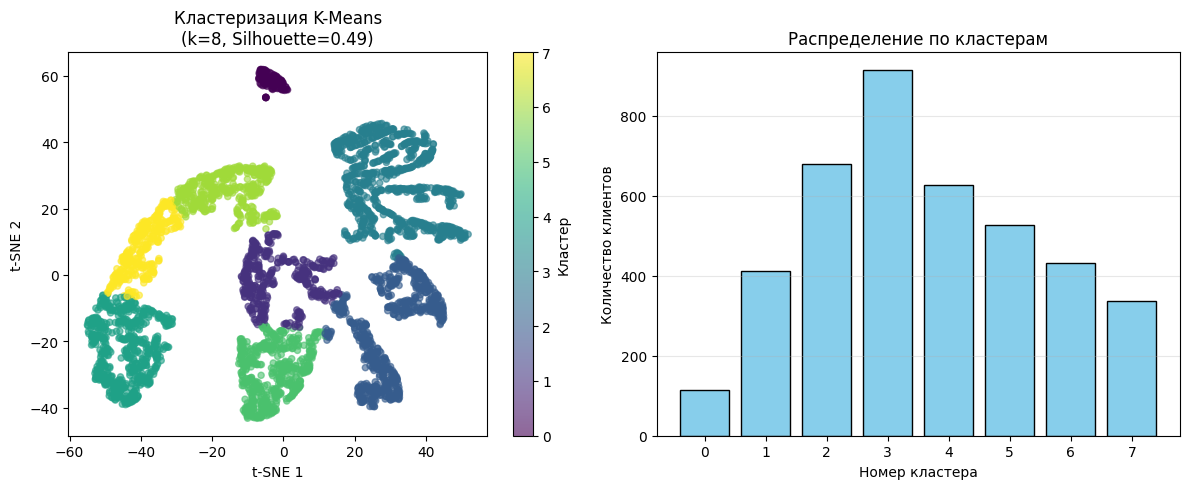

In [54]:
# Сравнение всех моделей
print("\nСРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ:")
print("=" * 50)
print(f"K-Means (k={best_k_kmeans}): {best_silhouette_kmeans:.4f}")
print(f"GaussianMixture (k={best_k_gmm}): {best_silhouette_gmm:.4f}")
print(f"AgglomerativeClustering (k={best_k_agg}): {best_silhouette_agg:.4f}")

# Определяем лучшую модель
models_comparison = {
    'K-Means': (best_k_kmeans, best_silhouette_kmeans),
    'GaussianMixture': (best_k_gmm, best_silhouette_gmm),
    'AgglomerativeClustering': (best_k_agg, best_silhouette_agg)
}

best_model_name = max(models_comparison, key=lambda x: models_comparison[x][1])
best_k_overall = models_comparison[best_model_name][0]
best_silhouette_overall = models_comparison[best_model_name][1]

print(f"\n1) Лучшая модель: {best_model_name}")
print(f"   Количество кластеров: {best_k_overall}")
print(f"   Коэффициент силуэта: {best_silhouette_overall:.4f}")

# Обучаем лучшую модель
if best_model_name == 'K-Means':
    best_model = KMeans(n_clusters=best_k_overall, random_state=42)
elif best_model_name == 'GaussianMixture':
    best_model = GaussianMixture(n_components=best_k_overall, random_state=42)
else:
    best_model = AgglomerativeClustering(n_clusters=best_k_overall)

# Применяем лучшую модель к t-SNE данным
best_cluster_labels = best_model.fit_predict(X_tsne)

# Анализируем распределение кластеров
unique, counts = np.unique(best_cluster_labels, return_counts=True)
cluster_distribution = dict(zip(unique, counts))

print(f"\nРаспределение клиентов по кластерам:")
for cluster_id, count in cluster_distribution.items():
    print(f"Кластер {cluster_id}: {count} клиентов")

# Находим самый большой кластер
largest_cluster_id = max(cluster_distribution, key=cluster_distribution.get)
largest_cluster_size = cluster_distribution[largest_cluster_id]

print(f"\n2) Количество клиентов в самом большом кластере: {largest_cluster_size}")

# Визуализация кластеров
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=best_cluster_labels, cmap='viridis', alpha=0.6, s=20)
plt.title(f'Кластеризация {best_model_name}\n(k={best_k_overall}, Silhouette={best_silhouette_overall:.2f})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Кластер')

plt.subplot(1, 2, 2)
plt.bar(cluster_distribution.keys(), cluster_distribution.values(), color='skyblue')
plt.title('Распределение по кластерам')
plt.xlabel('Номер кластера')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Итак, у нас есть 7 сегментов клиентов. Давайте попробуем составить профиль для этих сегментов. 


### Задание 6.6

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков. Для наглядности округлите все значения в столбцах до целого числа.

Чему равно максимальное среднее значение признака Recency в полученной таблице? Ответ округлите до целого числа.


ПРОФИЛИ КЛАСТЕРОВ (округлено до целых):
         Recency  Frequency  Monetary
Cluster                              
0            365          1       234
1            178          3       651
2             40          3       995
3             32          7      2416
4             44          1       325
5             38          2       599
6            282          1       355
7            157          1       271

Максимальное среднее значение признака Recency: 365


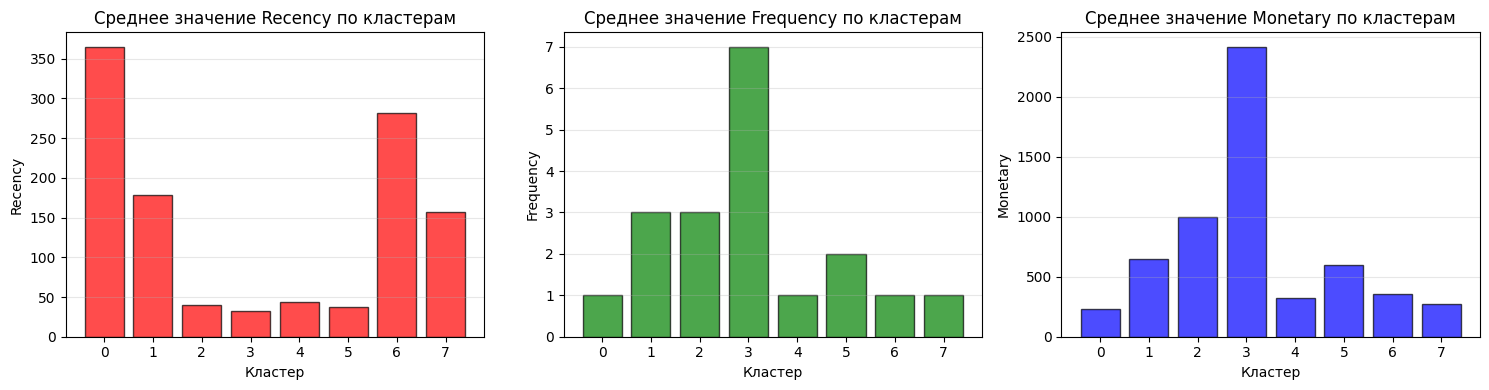

In [55]:
# Добавляем метки кластеров к исходным RFM данным
rfm_with_tsne_clusters = rfm_cleaned.copy()
rfm_with_tsne_clusters['Cluster'] = best_cluster_labels

# Группируем по кластерам и считаем средние значения
cluster_profiles_tsne = rfm_with_tsne_clusters.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(0).astype(int)  # Округляем до целых чисел

print("\nПРОФИЛИ КЛАСТЕРОВ (округлено до целых):")
print(cluster_profiles_tsne)

# Находим максимальное среднее значение Recency
max_recency = cluster_profiles_tsne['Recency'].max()

print(f"\nМаксимальное среднее значение признака Recency: {max_recency}")

# Визуализация профилей кластеров
plt.figure(figsize=(15, 4))

metrics = ['Recency', 'Frequency', 'Monetary']
colors = ['red', 'green', 'blue']

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    plt.bar(cluster_profiles_tsne.index, cluster_profiles_tsne[metric], color=colors[i], alpha=0.7)
    plt.title(f'Среднее значение {metric} по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel(metric)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Задание 6.7
Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера.

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «перспективным» клиентам, которые являются активными покупателями, но покупают не так часто и не так много, как лояльные клиенты.
* Кластер соответствует «подвисшим» клиентам, которые относительно недавно сделали несколько заказов на небольшие суммы. Потенциально эти клиенты могут быть переведены в кластер «перспективных».
* Кластер соответствует клиентам «в зоне риска», которые несколько раз покупали товары на небольшие суммы, однако их последняя покупка была совершена более пяти месяцев назад.
* Кластер соответствует клиентам-«новичкам», которые относительно недавно сделали один заказ на небольшую сумму. 
* Кластер соответствует «спящим» или «почти потерянным» клиентам, которые сделали один заказ на маленькую сумму более семи месяцев назад и больше не возвращались.
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена около года назад.



In [56]:
import plotly.graph_objects as go
from sklearn import preprocessing

# Функция для построения полярной диаграммы
def plot_cluster_profile_polar(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data_normalized = pd.DataFrame(scaler.fit_transform(grouped_data), 
                                         columns=grouped_data.columns)
    
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data_normalized.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
            opacity=0.7
        ))
    
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
        title='Профили кластеров (нормализованные значения)'
    )
    # Отображаем фигуру
    fig.show()

# Строим полярную диаграмму
print("ПОЛЯРНАЯ ДИАГРАММА ПРОФИЛЕЙ КЛАСТЕРОВ:")
plot_cluster_profile_polar(cluster_profiles_tsne, len(cluster_profiles_tsne))

# Анализируем каждый кластер
cluster_analysis = []

for cluster_id in cluster_profiles_tsne.index:
    recency = cluster_profiles_tsne.loc[cluster_id, 'Recency']
    frequency = cluster_profiles_tsne.loc[cluster_id, 'Frequency']
    monetary = cluster_profiles_tsne.loc[cluster_id, 'Monetary']
    size = cluster_distribution[cluster_id]
    
    cluster_analysis.append({
        'cluster_id': cluster_id,
        'recency': recency,
        'frequency': frequency,
        'monetary': monetary,
        'size': size
    })

ПОЛЯРНАЯ ДИАГРАММА ПРОФИЛЕЙ КЛАСТЕРОВ:


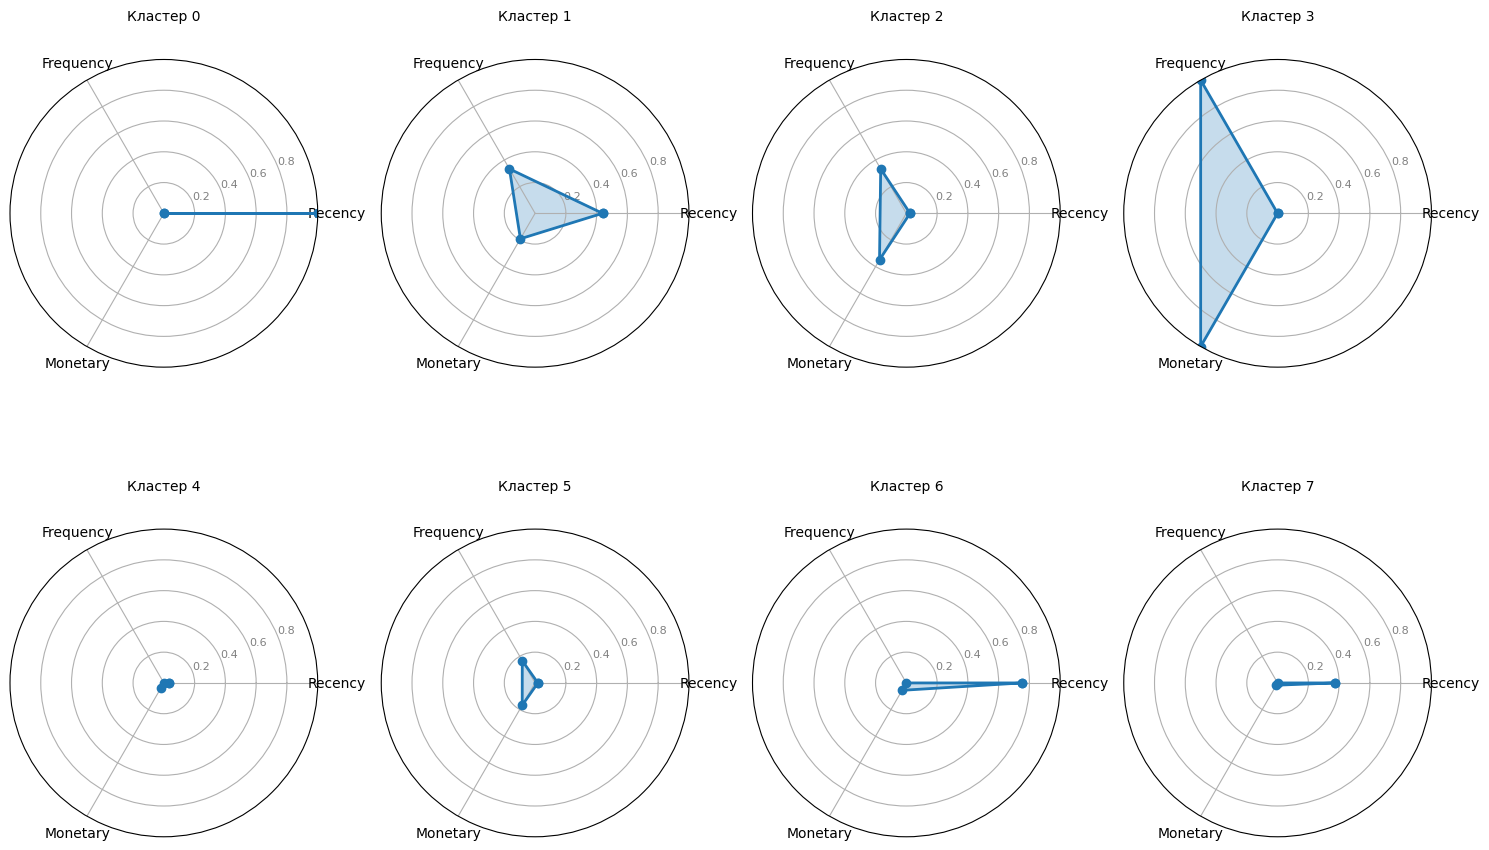

In [57]:
# Радарная диаграмма с matplotlib
plt.figure(figsize=(15, 10))

# Нормализуем данные для радарной диаграммы
scaler = preprocessing.MinMaxScaler()
cluster_profiles_normalized = pd.DataFrame(scaler.fit_transform(cluster_profiles_tsne), 
                                         columns=cluster_profiles_tsne.columns,
                                         index=cluster_profiles_tsne.index)

# Параметры для радарной диаграммы
categories = list(cluster_profiles_tsne.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Замыкаем круг

# Создаем субплотов для каждого кластера
n_clusters = len(cluster_profiles_tsne)
n_cols = min(4, n_clusters)
n_rows = (n_clusters + n_cols - 1) // n_cols

for i, cluster_id in enumerate(cluster_profiles_tsne.index):
    plt.subplot(n_rows, n_cols, i+1, polar=True)
    
    values = cluster_profiles_normalized.loc[cluster_id].values.tolist()
    values += values[:1]  # Замыкаем круг
    
    plt.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
    plt.fill(angles, values, alpha=0.25)
    plt.xticks(angles[:-1], categories)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
    plt.ylim(0, 1)
    plt.title(f'Кластер {cluster_id}', size=10, y=1.1)

plt.tight_layout()
plt.show()


## 7. RFM-кластеризация клиентов: часть 3

Мы построили модель кластеризации для части клиентов.Но как сделать предсказание сегмента для клиентов, которые не попали в обучающую выборку?

Вы, вероятно, скажете: «Воспользоваться методом predict()!»

Верно, однако всё не так просто.

Вспомним, что мы обучали наши алгоритмы кластеризации на сжатом с помощью t-SNE пространстве признаков. То есть, чтобы сделать предсказание для новых объектов, не попавших в выборку, нам необходимо будет совершить трансформацию признаков этих объектов в новое сжатое пространство. 

Однако проблема t-SNE заключается в том, что алгоритм непараметрический. Это значит, что он, в отличие от таких алгоритмов, как PCA и SVD, не создаёт явной функции отображения. Проще говоря, алгоритм трансформирует пространство признаков для обучающей выборки, но не запоминает, каким образом это делает. Это значит, что, передав в алгоритм новые объекты для сжатия пространства, мы получим абсолютно новое представление пространства, не имеющее отношения к тому, что мы построили для обучающей выборки. То есть произойдёт искажение, что может привести к неверным результатам кластеризации.

Именно поэтому у класса TSNE из библиотеки sklearn нет такого метода, как transform(), у него есть только метод fit_transform() — заново обучить алгоритм t-SNE и произвести трансформацию.

Как же тогда производить кластеризацию для новых объектов, если мы не можем сжимать размерность для новых данных?

Давайте сведём задачу кластеризации к задаче классификации. Действительно, у нас теперь есть истинные метки кластеров, а есть клиенты, которые описываются RFM-характеристиками. Давайте обучим модель, которая на основе RFM-характеристик будет предсказывать клиентский сегмент. 

### Задание 7.1

Разделите исходные данные на тренировочную и тестовую выборки в соотношении 80/20. В качестве параметра random_state возьмите число 42.

Сколько клиентов попали в тестовую выборку?

In [58]:
from sklearn.model_selection import train_test_split

X = rfm_cleaned
y = best_cluster_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)
X_test.shape

(809, 3)

Дальше нам осталось только построить несколько моделей и выбрать из них лучшую. 
Мы знаем, что алгоритм t-SNE является нелинейным методом понижения размерности. Можно смело предположить, что линейные модели, такие как логистическая регрессия, в данной задаче нам мало чем помогут (можете убедиться в этом самостоятельно, обучив модель логистической регрессии на тренировочной выборке и оценив качество на тестовой).

Поэтому давайте сразу возьмём тяжелую артиллерию — ансамблевые алгоритмы. 


### Задание 7.2
Начнём со случайного леса. С помощью GridSearchCV организуйте перебор параметров случайного леса (RandomForestClassifier) на следующей сетке параметров:

```
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}
```
В качестве параметра random_state для модели случайного леса используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5.

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в случайном лесу?

2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy'
)

%time grid_search.fit(X_train, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_test, y_test)))
y_test_pred = grid_search.predict(X_test)
print('accuracy на тестовом наборе: {:.2f}'.format(accuracy_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: total: 7min 16s
Wall time: 8min 25s
accuracy на тестовом наборе: 0.98


accuracy на тестовом наборе: 0.98
Наилучшие значения гиперпараметров: {'criterion': 'entropy', 'max_depth': 11, 'n_estimators': 500}


Итак, значение метрики accuracy очень высокое, но не идеальное. Давайте попробуем его улучшить, воспользовавшись бустингом.

### Задание 7.3
С помощью GridSearchCV организуйте перебор параметров градиентного бустинга (GradientBoostingClassifier) на следующей сетке параметров:
```
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
```

В качестве параметра random_state для модели градиентного бустинга используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5. 

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в градиентном бустинге?
2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [60]:
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy')

%time grid_search_gb.fit(X_train, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(grid_search_gb.score(X_test, y_test)))
y_test_pred = grid_search_gb.predict(X_test)
print('accuracy на тестовом наборе: {:.2f}'.format(accuracy_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search_gb.best_params_))

CPU times: total: 41min 19s
Wall time: 44min
accuracy на тестовом наборе: 0.98
accuracy на тестовом наборе: 0.98
Наилучшие значения гиперпараметров: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


Отлично, мы справились с проблемой непараметричности t-SNE и смогли перейти от решения задачи кластеризации к задаче классификации. Теперь у нас есть модель, которая на основе RFM-характерик клиента автоматически определяет его сегмент.